# Rope Flow — Full Pipeline (V01)
## Data-Driven Trajectory Reconstruction & Pattern Classification

**Course:** MECH 798M / EECE 798K — Data-Driven Modeling for Science & Engineering  
**Input:** 23 preprocessed sessions (50 Hz, dual-wrist IMU, `.xlsx` with Device_0 / Device_1 sheets)  
**Output:** Classified rope flow patterns with F1 evaluation metrics

**Pipeline:**
1. Data loading — all sessions + metadata labels
2. Preprocessing & cycle detection — Euler extraction, SavGol-based ||ω|| peak finding
3. SINDy — per-session equation discovery (orientation state ODE)
4. Trajectory reconstruction — baseline detrended integration + optional PINN corrector
5. DMD — per-cycle spectral decomposition on 12-channel sensor state
6. Feature engineering — 3-tier physics-grounded features (~28D per cycle)
7. Classification — Random Forest with leave-one-session-out CV
8. Summary & ablation

---
## 0. Setup & configuration

In [1]:
import os, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal, integrate
from scipy.linalg import svd
from scipy.interpolate import interp1d
from scipy.signal import detrend as scipy_detrend
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

# ── Paths ────────────────────────────────────────────────────
ROOT           = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath('.'))))
# Fallback: if running from src/Full pipeline/, ROOT is two levels up
if not os.path.isdir(os.path.join(ROOT, 'data')):
    ROOT = os.path.abspath(os.path.join('..', '..'))
DATA_RAW       = os.path.join(ROOT, 'data', 'raw', 'unified-data')
DATA_PROCESSED = os.path.join(ROOT, 'data', 'processed')
RESULTS_DIR    = os.path.join(ROOT, 'results', 'Full_pipeline')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Configuration ────────────────────────────────────────────
CONFIG = {
    # Cycle detection (must match Stage 1)
    'CYCLE_PROMINENCE_DEGS': 100.0,      # deg/s
    'CYCLE_MIN_PERIOD_S':    0.5,         # seconds
    # SINDy
    'SINDY_THRESHOLD':       0.1,         # STLSQ sparsity threshold
    'SINDY_POLY_DEGREE':     2,
    'SINDY_N_FREQ':          1,
    # PINN
    'USE_PINN':              False,        # set True for full run (~20 min)
    'PINN_EPOCHS':           300,
    'PINN_CYCLES_PER_SESSION': 3,
    'PINN_LAM':              1.0,
    'PINN_LAM_SYM':          0.5,
    'PINN_LR':               3e-4,
    'PINN_HIDDEN':           128,
    'PINN_LAYERS':           5,
    # DMD
    'DMD_VAR_THRESHOLD':     0.99,
    # Features
    'TARGET_LEN':            64,           # resampling length for per-cycle matrices
    # Classification
    'RF_N_ESTIMATORS':       200,
    'RANDOM_SEED':           42,
}

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
PAL = {
    'underhand': '#5DCAA5', 'overhand': '#7F77DD', 'dragon_roll': '#E24B4A',
    'sneak_underhand': '#EF9F27', 'sneak_overhand': '#D85A30',
    'race_and_chase': '#3498db', 'cheetahs_tail': '#e74c3c',
    'experimental': '#888780',
    'dev0': '#5DCAA5', 'dev1': '#7F77DD',
    'naive': '#E24B4A', 'pinn': '#EF9F27', 'gray': '#888780',
}

t_start = time.time()
print(f'ROOT: {ROOT}')
print(f'USE_PINN: {CONFIG["USE_PINN"]}')

ROOT: c:\Users\Admin\Projects\ropeflow-project
USE_PINN: False


---
## 1. Data loading — all 23 sessions

In [2]:
# ── Discover sessions: match processed xlsx with raw metadata ────
xlsx_files = sorted(glob.glob(os.path.join(DATA_PROCESSED, '202603*_processed.xlsx')))

sessions = []
for xf in xlsx_files:
    name = os.path.basename(xf).replace('_processed.xlsx', '')
    meta_path = os.path.join(DATA_RAW, name, 'metadata.json')
    if not os.path.isfile(meta_path):
        print(f'  SKIP {name} — no metadata.json')
        continue
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    sessions.append({
        'name':     name,
        'xlsx':     xf,
        'pattern':  meta.get('pattern', 'unknown'),
        'category': meta.get('pattern_category', 'Other'),
        'subject':  meta.get('subject', 'unknown'),
        'duration': meta.get('duration_sec', 0),
    })

# Label sessions: 'experimental' excluded from supervised training
for s in sessions:
    s['is_labeled'] = s['pattern'] != 'experimental'

n_labeled = sum(s['is_labeled'] for s in sessions)
n_exp     = sum(not s['is_labeled'] for s in sessions)
patterns  = sorted(set(s['pattern'] for s in sessions if s['is_labeled']))

print(f'Sessions loaded: {len(sessions)} total  '
      f'({n_labeled} labeled, {n_exp} experimental)\n')
print(f'{"Pattern":<20s} {"Count":>5s}  Sessions')
print('-' * 60)
for pat in patterns:
    ss = [s for s in sessions if s['pattern'] == pat]
    names = ', '.join(s['subject'] for s in ss)
    print(f'{pat:<20s} {len(ss):>5d}  {names}')
ss_exp = [s for s in sessions if not s['is_labeled']]
print(f'{"experimental":<20s} {len(ss_exp):>5d}  (excluded from classifier)')

Sessions loaded: 23 total  (13 labeled, 10 experimental)

Pattern              Count  Sessions
------------------------------------------------------------
cheetahs_tail            1  jo
dragon_roll              2  oli, jo
overhand                 2  oli, jo
race_and_chase           1  jo
sneak_overhand           2  oli, jo
sneak_underhand          1  jo
underhand                4  default, default, jo, oli
experimental            10  (excluded from classifier)


In [3]:
# ── Load all xlsx data into memory ──────────────────────────
for s in sessions:
    s['d0'] = pd.read_excel(s['xlsx'], sheet_name='Device_0')
    s['d1'] = pd.read_excel(s['xlsx'], sheet_name='Device_1')

total_samples = sum(len(s['d0']) + len(s['d1']) for s in sessions)
print(f'Loaded {total_samples:,} samples across {len(sessions)} sessions')

Loaded 223,419 samples across 23 sessions


---
## 2. Preprocessing & cycle detection

In [4]:
def preprocess(df):
    """
    Extract signals from a processed device DataFrame.
    Builds SINDy orientation state O with sin/cos encoding for roll and yaw
    to avoid discontinuities at +/-pi in the library.

    Returns
    -------
    t     : (N,)   time [s]
    Q     : (N,4)  quaternion [qw, qx, qy, qz]
    A     : (N,3)  world-frame linear acceleration [m/s^2]
    omega : (N,3)  angular velocity [rad/s]
    O     : (N,8)  SINDy state [sin(r), cos(r), pitch, sin(y), cos(y), wx, wy, wz]
    """
    t = df['timestamp_ms'].values / 1000.0
    Q = df[['qw','qx','qy','qz']].values
    A = df[['ax_w','ay_w','az_w']].values
    omega = df[['gx','gy','gz']].values * (np.pi / 180.0)  # deg/s -> rad/s

    qw, qx, qy, qz = Q[:,0], Q[:,1], Q[:,2], Q[:,3]
    roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1, 1))
    yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

    O = np.column_stack([
        np.sin(roll), np.cos(roll), pitch,
        np.sin(yaw),  np.cos(yaw),
        omega
    ])
    return t, Q, A, omega, O


SINDY_STATE_NAMES = ['sin_r', 'cos_r', 'pitch', 'sin_y', 'cos_y', 'wx', 'wy', 'wz']

In [5]:
PROM_RADS = CONFIG['CYCLE_PROMINENCE_DEGS'] * np.pi / 180.0

def detect_cycles(t, omega, label=''):
    """
    Detect rope-flow cycles from ||omega(t)||.
    Replicates Stage 1: SavGol smoothing + physical prominence threshold.
    Boundaries at midpoints between consecutive peaks.
    """
    mag        = np.linalg.norm(omega, axis=1)
    mag_smooth = signal.savgol_filter(mag, window_length=15, polyorder=3)
    sr         = 1.0 / np.median(np.diff(t))
    min_dist   = int(CONFIG['CYCLE_MIN_PERIOD_S'] * sr)

    peaks, _ = signal.find_peaks(mag_smooth, distance=min_dist,
                                 prominence=PROM_RADS)
    if len(peaks) < 2:
        return [], mag_smooth, peaks

    bounds = ([0]
              + [(peaks[i]+peaks[i+1])//2 for i in range(len(peaks)-1)]
              + [len(t)-1])
    cycles = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]
    return cycles, mag_smooth, peaks


def pair_cycles_by_overlap(t0, cycles0, t1, cycles1):
    """
    Match each Device 0 cycle to the Device 1 cycle with maximum
    time-window overlap. Each Device 1 cycle is used at most once.
    """
    def overlap(s0, e0, s1, e1):
        return max(0.0, min(t0[e0], t1[e1]) - max(t0[s0], t1[s1]))

    paired0, paired1, used = [], [], set()
    for c0 in cycles0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cycles1):
            if i in used:
                continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cycles1[best_idx])
            used.add(best_idx)
    return paired0, paired1

In [ ]:
# ── Run preprocessing + cycle detection on all sessions ─────
print(f'{"Session":<45s} {"D0 cyc":>6s} {"D1 cyc":>6s} {"Paired":>6s}  Status')
print('-' * 80)

skipped_sessions = []

for s in sessions:
    t0, Q0, A0, om0, O0 = preprocess(s['d0'])
    t1, Q1, A1, om1, O1 = preprocess(s['d1'])

    cyc0, sm0, pk0 = detect_cycles(t0, om0)
    cyc1, sm1, pk1 = detect_cycles(t1, om1)

    if len(cyc0) > 0 and len(cyc1) > 0:
        p0, p1 = pair_cycles_by_overlap(t0, cyc0, t1, cyc1)
    else:
        p0, p1 = [], []

    # Flag sessions with 0 paired cycles as outliers
    if len(p0) == 0:
        s['skip'] = True
        reason = []
        if len(cyc0) == 0: reason.append('D0: 0 peaks')
        if len(cyc1) == 0: reason.append('D1: 0 peaks')
        if not reason:     reason.append('0 paired cycles')
        s['skip_reason'] = ', '.join(reason)
        skipped_sessions.append(s)
    else:
        s['skip'] = False
        s['skip_reason'] = ''

    s['proc'] = {
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1,
        'om0': om0, 'om1': om1, 'O0': O0, 'O1': O1,
        'cycles0': cyc0, 'cycles1': cyc1,
        'paired0': p0, 'paired1': p1,
    }
    status = f'SKIP ({s["skip_reason"]})' if s['skip'] else 'OK'
    print(f'{s["name"]:<45s} {len(cyc0):>6d} {len(cyc1):>6d} {len(p0):>6d}  {status}')

# Filter to active sessions for all downstream processing
active_sessions = [s for s in sessions if not s['skip']]

total_paired = sum(len(s['proc']['paired0']) for s in active_sessions)
print(f'\nActive sessions: {len(active_sessions)} / {len(sessions)}')
print(f'Total paired cycles: {total_paired}')
if skipped_sessions:
    print(f'\nSkipped ({len(skipped_sessions)} sessions — 0 usable cycles):')
    for s in skipped_sessions:
        print(f'  {s["name"]}: {s["skip_reason"]}')

In [ ]:
# ── Diagnostic: cycle counts by pattern ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names   = [s['name'].split('_', 2)[-1] for s in active_sessions]
counts  = [len(s['proc']['paired0']) for s in active_sessions]
colors  = [PAL.get(s['pattern'], PAL['gray']) for s in active_sessions]
bars    = ax.barh(range(len(active_sessions)), counts, color=colors, alpha=0.85)
ax.set_yticks(range(len(active_sessions)))
ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel('Paired cycles')
ax.set_title('Cycle count per session (colored by pattern)')
ax.invert_yaxis()

# Legend
used = set()
handles = []
for s in active_sessions:
    if s['pattern'] not in used:
        handles.append(Line2D([0],[0], color=PAL.get(s['pattern'], PAL['gray']),
                              lw=6, label=s['pattern']))
        used.add(s['pattern'])
ax.legend(handles=handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cycle_counts.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. SINDy — per-session equation discovery

Fit SINDy on the 8D orientation state $O = [\sin r, \cos r, p, \sin y, \cos y, \omega_x, \omega_y, \omega_z]$  
using a **GeneralizedLibrary** (polynomial degree 2 + Fourier with 1 frequency).  
Each session is fit independently — different patterns have genuinely different governing dynamics.

In [8]:
def fit_sindy_session(O0, t0, O1, t1, threshold=None):
    """
    Fit SINDy on the joint orientation state (both devices stacked).
    Returns model, scores, coefficient matrix.
    """
    th = threshold or CONFIG['SINDY_THRESHOLD']
    X_joint = np.vstack([O0, O1])
    t_joint = np.concatenate([t0, t1 + t0[-1] + 0.02])

    library = ps.GeneralizedLibrary([
        ps.PolynomialLibrary(degree=CONFIG['SINDY_POLY_DEGREE'], include_bias=True),
        ps.FourierLibrary(n_frequencies=CONFIG['SINDY_N_FREQ'])
    ])
    optimizer = ps.STLSQ(threshold=th, alpha=0.05, max_iter=20)
    diff_method = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11})

    model = ps.SINDy(feature_library=library, optimizer=optimizer,
                     differentiation_method=diff_method)
    model.fit(X_joint, t=t_joint)

    r2_joint = model.score(X_joint, t=t_joint)
    r2_dev0  = model.score(O0, t=t0)
    r2_dev1  = model.score(O1, t=t1)
    coef     = model.coefficients()

    return {
        'model':    model,
        'r2_joint': r2_joint,
        'r2_dev0':  r2_dev0,
        'r2_dev1':  r2_dev1,
        'coef':     coef,
        'n_active': int((coef != 0).sum()),
        'sparsity': float((coef == 0).mean()),
    }

In [ ]:
# ── Run SINDy on all active sessions ─────────────────────────
print(f'{"Session":<45s} {"R2_joint":>8s} {"R2_cross":>8s} {"Active":>6s} {"Sparsity":>8s}')
print('-' * 80)

for s in active_sessions:
    p = s['proc']
    s['sindy'] = fit_sindy_session(p['O0'], p['t0'], p['O1'], p['t1'])
    sd = s['sindy']
    print(f'{s["name"]:<45s} {sd["r2_joint"]:>8.4f} {sd["r2_dev1"]:>8.4f} '
          f'{sd["n_active"]:>6d} {sd["sparsity"]:>7.1%}')

In [ ]:
# ── Diagnostic: coefficient heatmap grouped by pattern ───────
labeled_s = [s for s in active_sessions if s['is_labeled']]
labeled_s_sorted = sorted(labeled_s, key=lambda s: s['pattern'])

coef_stack = np.array([np.abs(s['sindy']['coef']).ravel() for s in labeled_s_sorted])
coef_stack_log = np.log10(coef_stack + 1e-10)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(coef_stack_log, aspect='auto', cmap='Purples', interpolation='nearest')
ax.set_yticks(range(len(labeled_s_sorted)))
ax.set_yticklabels([f'{s["pattern"]}_{s["subject"]}' for s in labeled_s_sorted], fontsize=7)
ax.set_xlabel('Flattened coefficient index')
ax.set_title('SINDy coefficient magnitude (log10) — grouped by pattern\n'
             'Similar sparsity structure within a pattern = consistent dynamics')
plt.colorbar(im, ax=ax, label='log10(|coef|)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sindy_coef_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Trajectory reconstruction

### 4.1 Baseline integration (all cycles)

Per-cycle double integration of world-frame linear acceleration with **linear detrending**.  
Detrending removes both mean and linear trend — any residual linear trend is sensor bias  
(gravity residual from Stage 1) that integrates to a cubic position error.

In [11]:
def integrate_cycle(t, A, s, e):
    """Double-integrate acceleration within one cycle using linear detrending."""
    tc = t[s:e]
    if len(tc) < 4:
        return tc, np.zeros((len(tc), 3)), np.zeros((len(tc), 3))
    Ac = np.column_stack([scipy_detrend(A[s:e, d]) for d in range(3)])
    v  = np.column_stack([
        integrate.cumulative_trapezoid(Ac[:, d], tc, initial=0) for d in range(3)])
    p  = np.column_stack([
        integrate.cumulative_trapezoid(v[:, d],  tc, initial=0) for d in range(3)])
    return tc, v, p

In [ ]:
# ── Run baseline integration on all paired cycles ────────────
for s in active_sessions:
    p = s['proc']
    baseline0, baseline1 = [], []
    for (s0, e0), (s1, e1) in zip(p['paired0'], p['paired1']):
        tc0, v0, p0 = integrate_cycle(p['t0'], p['A0'], s0, e0)
        tc1, v1, p1 = integrate_cycle(p['t1'], p['A1'], s1, e1)
        baseline0.append({'t': tc0, 'v': v0, 'p': p0, 's': s0, 'e': e0})
        baseline1.append({'t': tc1, 'v': v1, 'p': p1, 's': s1, 'e': e1})
    s['baseline0'] = baseline0
    s['baseline1'] = baseline1
    drift0 = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in baseline0 if len(c['p']) > 1]
    drift1 = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in baseline1 if len(c['p']) > 1]
    s['baseline_drift0'] = np.mean(drift0) if drift0 else 0.0
    s['baseline_drift1'] = np.mean(drift1) if drift1 else 0.0

print(f'{"Session":<45s} {"Drift D0":>8s} {"Drift D1":>8s}')
print('-' * 65)
for s in active_sessions:
    print(f'{s["name"]:<45s} {s["baseline_drift0"]:>8.4f} {s["baseline_drift1"]:>8.4f}')

### 4.2 PINN correction (representative cycles)

**Gated by `CONFIG['USE_PINN']`** — skip this section for fast iteration.  
When enabled, trains a PINN corrector on 3 representative cycles per session (300 epochs).  
The PINN learns a position correction $\delta p(t)$ on top of the baseline trajectory,  
enforcing **periodic boundary conditions** $p(T) \approx p(0)$, **velocity closure**,  
**arm-length boundary**, and **jerk minimization** (not zeroed — preserves dynamics).

In [13]:
class PINNCorrectorNet(nn.Module):
    """
    Learns position correction delta_p(t) on top of baseline trajectory.
    Input (8D): [t_norm, sin(2pi*t), cos(2pi*t), sin(4pi*t), cos(4pi*t), ax, ay, az]
    Xavier init with small gain keeps delta_p near zero initially.
    """
    def __init__(self, hidden_dim=128, n_layers=5):
        super().__init__()
        layers = [nn.Linear(8, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=0.1)
                nn.init.zeros_(layer.bias)

    def forward(self, feats):
        return self.net(feats)


def make_features(tc, Ac_dt):
    """Build 8D input feature tensor for one cycle."""
    T      = tc[-1] - tc[0]
    t_norm = (tc - tc[0]) / (T + 1e-8)
    return torch.tensor(np.column_stack([
        t_norm,
        np.sin(2*np.pi*t_norm), np.cos(2*np.pi*t_norm),
        np.sin(4*np.pi*t_norm), np.cos(4*np.pi*t_norm),
        Ac_dt
    ]), dtype=torch.float32)


def physics_losses(p, v, tc, R_arm=0.65):
    """
    Physics regularisation for one device trajectory.
    Returns dict of individual loss terms.
    """
    periodic_p = torch.sum((p[-1] - p[0])**2)
    periodic_v = torch.sum((v[-1] - v[0])**2)
    boundary   = torch.mean(torch.relu(torch.norm(p, dim=1) - R_arm)**2)
    # Jerk: minimised, not zeroed — preserves meaningful dynamics
    dp  = torch.diff(p, dim=0)
    ddp = torch.diff(dp, dim=0)
    jerk = torch.mean(torch.diff(ddp, dim=0)**2) if len(p) > 3 else torch.tensor(0.0)
    # Energy: penalise kinetic energy variance (smooth motion)
    ke   = 0.5 * torch.sum(v**2, dim=1)
    energy = torch.var(ke)
    return {'periodic_p': periodic_p, 'periodic_v': periodic_v,
            'boundary': boundary, 'jerk': jerk, 'energy': energy}


def train_pinn_pair(cyc0, cyc1, A0_full, A1_full,
                    lam=1.0, lam_sym=0.5, epochs=300, lr=3e-4):
    """
    Train two PINN correctors jointly for one paired cycle.
    Symmetry loss couples trajectories via the rope midpoint.
    """
    s0, e0 = cyc0['s'], cyc0['e']
    s1, e1 = cyc1['s'], cyc1['e']
    tc0, tc1 = cyc0['t'], cyc1['t']

    Ac0 = np.column_stack([scipy_detrend(A0_full[s0:e0, d]) for d in range(3)])
    Ac1 = np.column_stack([scipy_detrend(A1_full[s1:e1, d]) for d in range(3)])

    feats0 = make_features(tc0, Ac0)
    feats1 = make_features(tc1, Ac1)
    pb0    = torch.tensor(cyc0['p'], dtype=torch.float32)
    pb1    = torch.tensor(cyc1['p'], dtype=torch.float32)
    Aobs0  = torch.tensor(Ac0, dtype=torch.float32)
    Aobs1  = torch.tensor(Ac1, dtype=torch.float32)
    dt0    = float(np.median(np.diff(tc0)))
    dt1    = float(np.median(np.diff(tc1)))

    net0 = PINNCorrectorNet(CONFIG['PINN_HIDDEN'], CONFIG['PINN_LAYERS'])
    net1 = PINNCorrectorNet(CONFIG['PINN_HIDDEN'], CONFIG['PINN_LAYERS'])
    params = list(net0.parameters()) + list(net1.parameters())
    opt    = optim.Adam(params, lr=lr)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        opt.zero_grad()
        p0 = pb0 + net0(feats0)
        p1 = pb1 + net1(feats1)
        v0 = torch.diff(p0, dim=0) / dt0
        v1 = torch.diff(p1, dim=0) / dt1

        # Acceleration consistency (data loss)
        a0_pred = torch.diff(v0, dim=0) / dt0
        a1_pred = torch.diff(v1, dim=0) / dt1
        data0 = torch.mean((a0_pred - Aobs0[2:])**2)
        data1 = torch.mean((a1_pred - Aobs1[2:])**2)

        phys0 = physics_losses(p0, v0, tc0)
        phys1 = physics_losses(p1, v1, tc1)

        # Symmetry: rope midpoint should be stable
        n_min = min(len(p0), len(p1))
        mid   = 0.5 * (p0[:n_min] + p1[:n_min])
        symmetry = torch.var(mid, dim=0).sum()

        loss = (data0 + data1
                + 5.0 * (phys0['periodic_p'] + phys1['periodic_p'])
                + 2.0 * (phys0['periodic_v'] + phys1['periodic_v'])
                + lam * (phys0['boundary'] + phys0['jerk'] + phys0['energy']
                       + phys1['boundary'] + phys1['jerk'] + phys1['energy'])
                + lam_sym * symmetry)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        opt.step()
        sched.step()

    with torch.no_grad():
        p0_out = (pb0 + net0(feats0)).numpy()
        p1_out = (pb1 + net1(feats1)).numpy()
    return p0_out, p1_out

In [ ]:
# ── Run PINN on representative cycles (if enabled) ───────────
if CONFIG['USE_PINN']:
    n_rep = CONFIG['PINN_CYCLES_PER_SESSION']
    print(f'PINN enabled: {n_rep} cycles/session x {CONFIG["PINN_EPOCHS"]} epochs\n')

    for si, s in enumerate(active_sessions):
        p = s['proc']
        n_paired = len(p['paired0'])
        if n_paired == 0:
            s['pinn0'], s['pinn1'], s['pinn_indices'] = [], [], []
            continue

        # Select cycles closest to median duration
        durations = [p['t0'][e] - p['t0'][ss] for ss, e in p['paired0']]
        med_dur   = np.median(durations)
        ranked    = np.argsort(np.abs(np.array(durations) - med_dur))
        sel       = ranked[:min(n_rep, n_paired)]

        pinn0, pinn1 = [], []
        for k in sel:
            p0c, p1c = train_pinn_pair(
                s['baseline0'][k], s['baseline1'][k],
                p['A0'], p['A1'],
                lam=CONFIG['PINN_LAM'], lam_sym=CONFIG['PINN_LAM_SYM'],
                epochs=CONFIG['PINN_EPOCHS'], lr=CONFIG['PINN_LR'])
            pinn0.append({'p': p0c, **{x: s['baseline0'][k][x] for x in ['t','s','e']}})
            pinn1.append({'p': p1c, **{x: s['baseline1'][k][x] for x in ['t','s','e']}})

        s['pinn0'] = pinn0
        s['pinn1'] = pinn1
        s['pinn_indices'] = sel.tolist()

        # Report drift reduction
        bd = [np.linalg.norm(s['baseline0'][k]['p'][-1] - s['baseline0'][k]['p'][0]) for k in sel]
        pd_ = [np.linalg.norm(pc['p'][-1] - pc['p'][0]) for pc in pinn0]
        red = 100 * (1 - np.mean(pd_) / (np.mean(bd) + 1e-8))
        if (si % 5 == 0) or (si == len(active_sessions) - 1):
            print(f'  [{si+1:2d}/{len(active_sessions)}] {s["name"]:<40s} '
                  f'drift {np.mean(bd):.4f} -> {np.mean(pd_):.4f} m ({red:.0f}%)')

    print('\nPINN complete.')
else:
    print('PINN disabled (CONFIG["USE_PINN"] = False). '
          'Using baseline integration only.\n'
          'Set USE_PINN = True and re-run for PINN-corrected trajectories.')

In [ ]:
# ── Diagnostic: 3D trajectory plots for first 3 labeled sessions ───
show_sessions = [s for s in active_sessions if s['is_labeled']][:3]
fig = plt.figure(figsize=(5 * len(show_sessions), 5))

for col, s in enumerate(show_sessions):
    # Use PINN if available, else baseline
    if CONFIG['USE_PINN'] and len(s.get('pinn0', [])) > 0:
        p0 = s['pinn0'][0]['p']
        p1 = s['pinn1'][0]['p']
        title_tag = 'PINN'
    elif len(s['baseline0']) > 0:
        p0 = s['baseline0'][0]['p']
        p1 = s['baseline1'][0]['p']
        title_tag = 'baseline'
    else:
        continue

    n = min(len(p0), len(p1))
    p0, p1 = p0[:n], p1[:n]
    t_norm = np.linspace(0, 1, n)

    ax = fig.add_subplot(1, len(show_sessions), col + 1, projection='3d')
    for i in range(n - 1):
        ax.plot(p0[i:i+2,0], p0[i:i+2,1], p0[i:i+2,2],
                color=plt.cm.plasma(t_norm[i]), lw=1.5)
        ax.plot(p1[i:i+2,0], p1[i:i+2,1], p1[i:i+2,2],
                color=plt.cm.viridis(t_norm[i]), lw=1.5)
    ax.set_title(f'{s["pattern"]}_{s["subject"]}\n({title_tag}, cycle 0)', fontsize=9)
    ax.set_xlabel('X', fontsize=7); ax.set_ylabel('Y', fontsize=7)
    ax.set_zlabel('Z', fontsize=7); ax.tick_params(labelsize=6)

plt.suptitle('Reconstructed 3D hand trajectories (cycle 0)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'trajectory_3d.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. DMD — per-cycle spectral decomposition

Exact DMD with automatic rank selection (99% variance threshold).  
State vector: 12 channels $[a_{0,xyz}, \omega_{0,xyz}, a_{1,xyz}, \omega_{1,xyz}]$ from raw sensor data  
(no PINN dependency — position is supplementary when available).

In [16]:
def compute_dmd(X, dt, var_threshold=0.99):
    """
    Exact DMD with automatic rank selection.
    Rank r = minimum SVD modes explaining var_threshold of total variance.

    Returns: continuous eigenvalues, DMD modes, frequencies (Hz),
             growth rates, mode amplitudes, rank, singular values.
    """
    X1, X2 = X[:, :-1], X[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    r = int(np.searchsorted(np.cumsum(S**2) / np.sum(S**2), var_threshold)) + 1
    r = min(r, len(S))  # guard against edge cases
    U_r, S_r, Vh_r = U[:,:r], S[:r], Vh[:r,:]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ np.diag(1.0 / S_r)
    lam_d, W = np.linalg.eig(A_tilde)
    Phi   = X2 @ Vh_r.T @ np.diag(1.0 / S_r) @ W
    lam_c = np.log(lam_d + 1e-12) / dt
    b     = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]
    return lam_c, Phi, np.abs(lam_c.imag) / (2*np.pi), lam_c.real, b, r, S

In [ ]:
# ── Run DMD on all paired cycles ─────────────────────────────
for s in active_sessions:
    p = s['proc']
    dmd_results = []
    for k, ((s0, e0), (s1, e1)) in enumerate(zip(p['paired0'], p['paired1'])):
        n = min(e0 - s0, e1 - s1)
        if n < 10:
            dmd_results.append(None)
            continue
        # 12-channel state: [a0_xyz, omega0_xyz, a1_xyz, omega1_xyz]
        state = np.hstack([
            p['A0'][s0:s0+n],  p['om0'][s0:s0+n],
            p['A1'][s1:s1+n],  p['om1'][s1:s1+n],
        ]).T  # (12, n)
        dt_ = float(np.median(np.diff(p['t0'][s0:s0+n])))
        try:
            lam_c, Phi, freqs, growth, b, r, S = compute_dmd(
                state, dt_, CONFIG['DMD_VAR_THRESHOLD'])
            dmd_results.append({
                'lam_c': lam_c, 'freqs': freqs, 'growth': growth,
                'b': b, 'r': r, 'S': S,
            })
        except Exception:
            dmd_results.append(None)
    s['dmd'] = dmd_results

# Summary
valid_ranks = [r['r'] for s in active_sessions for r in s['dmd'] if r is not None]
print(f'DMD complete: {len(valid_ranks)} valid cycles')
print(f'  Rank: mean={np.mean(valid_ranks):.1f}  '
      f'range=[{min(valid_ranks)}, {max(valid_ranks)}]')

In [ ]:
# ── Diagnostic: DMD eigenvalue spectrum colored by pattern ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s in active_sessions:
    if not s['is_labeled']:
        continue
    col = PAL.get(s['pattern'], PAL['gray'])
    for res in s['dmd']:
        if res is None:
            continue
        axes[0].scatter(res['lam_c'].real, res['lam_c'].imag / (2*np.pi),
                        s=10, alpha=0.3, color=col)
axes[0].axvline(0, color=PAL['gray'], lw=1.0, ls='--')
axes[0].set_xlabel('Growth rate')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('DMD eigenvalue spectrum (labeled sessions)\n'
                  'Modes near growth=0 are stable oscillations')

# Dominant frequency per cycle, grouped by pattern
for s in active_sessions:
    if not s['is_labeled']:
        continue
    col = PAL.get(s['pattern'], PAL['gray'])
    dom_freqs = []
    for res in s['dmd']:
        if res is None:
            continue
        top = np.argsort(np.abs(res['b']))[::-1][0]
        dom_freqs.append(res['freqs'][top])
    if dom_freqs:
        axes[1].scatter([s['pattern']] * len(dom_freqs), dom_freqs,
                        s=15, alpha=0.4, color=col)
axes[1].set_ylabel('Dominant DMD frequency (Hz)')
axes[1].set_title('Dominant frequency by pattern')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Stage 2C — DMD spectral analysis', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dmd_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature engineering

Three-tier feature strategy — all physically motivated:

| Tier | Source | Dim | Scope |
|------|--------|-----|-------|
| 1 | Physics-grounded | 12 | per cycle |
| 2 | DMD spectral | 7 | per cycle |
| 3 | SINDy structural | 9 | per session (broadcast) |

In [19]:
def compute_physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1):
    """
    Tier 1: 12D physics-grounded feature vector per paired cycle.

    1.  cycle_period_s       — cycle duration
    2.  peak_omega_mag       — max ||omega|| across both devices
    3.  dominant_freq_hz     — FFT peak of ||omega0|| (fundamental rope frequency)
    4-6. mean_abs_acc_dev0   — mean |a_x|, |a_y|, |a_z| (world frame)
    7-9. mean_abs_acc_dev1
    10. acc_asymmetry        — ||mean(|A0|)|| / ||mean(|A1|)|| ratio
    11. omega_std_ratio      — std(||omega0||) / std(||omega1||)
    12. phase_lag_ms         — cross-correlation peak offset between ||omega0|| and ||omega1||
    """
    tc0 = t0[s0:e0]
    tc1 = t1[s1:e1]
    a0  = A0[s0:e0]
    a1  = A1[s1:e1]
    w0  = om0[s0:e0]
    w1  = om1[s1:e1]

    # 1. Cycle period
    period = tc0[-1] - tc0[0]

    # 2. Peak angular velocity magnitude
    mag0 = np.linalg.norm(w0, axis=1)
    mag1 = np.linalg.norm(w1, axis=1)
    peak_omega = max(np.max(mag0), np.max(mag1))

    # 3. Dominant frequency from FFT of ||omega0||
    fs = 1.0 / np.median(np.diff(tc0)) if len(tc0) > 1 else 50.0
    fft_mag = np.abs(np.fft.rfft(mag0 - mag0.mean()))
    fft_freqs = np.fft.rfftfreq(len(mag0), d=1.0/fs)
    # Exclude DC and very low freq
    valid = fft_freqs > 0.3
    dom_freq = fft_freqs[valid][np.argmax(fft_mag[valid])] if np.any(valid) else 0.0

    # 4-9. Mean absolute acceleration per axis
    ma0 = np.mean(np.abs(a0), axis=0)  # [3]
    ma1 = np.mean(np.abs(a1), axis=0)  # [3]

    # 10. Acceleration asymmetry
    acc_asym = np.linalg.norm(ma0) / (np.linalg.norm(ma1) + 1e-8)

    # 11. Angular velocity std ratio
    std0 = np.std(mag0)
    std1 = np.std(mag1)
    omega_ratio = std0 / (std1 + 1e-8)

    # 12. Phase lag via cross-correlation of ||omega||
    n_min = min(len(mag0), len(mag1))
    if n_min > 4:
        m0 = mag0[:n_min] - mag0[:n_min].mean()
        m1 = mag1[:n_min] - mag1[:n_min].mean()
        corr = np.correlate(m0, m1, mode='full')
        lag_samples = np.argmax(corr) - (n_min - 1)
        phase_lag = lag_samples / fs * 1000  # ms
    else:
        phase_lag = 0.0

    return np.array([
        period, peak_omega, dom_freq,
        ma0[0], ma0[1], ma0[2],
        ma1[0], ma1[1], ma1[2],
        acc_asym, omega_ratio, phase_lag
    ])


TIER1_NAMES = [
    'period_s', 'peak_omega', 'dom_freq_hz',
    'mean_acc_x_d0', 'mean_acc_y_d0', 'mean_acc_z_d0',
    'mean_acc_x_d1', 'mean_acc_y_d1', 'mean_acc_z_d1',
    'acc_asymmetry', 'omega_std_ratio', 'phase_lag_ms'
]

In [20]:
def compute_dmd_features(dmd_result, n_top=3):
    """
    Tier 2: 7D DMD spectral feature vector.
    Top-3 frequencies, top-3 growth rates, DMD rank.
    """
    if dmd_result is None:
        return np.zeros(2 * n_top + 1)
    top = np.argsort(np.abs(dmd_result['b']))[::-1][:n_top]
    # Pad if fewer than n_top modes
    freqs  = np.zeros(n_top)
    growth = np.zeros(n_top)
    for i, idx in enumerate(top):
        freqs[i]  = dmd_result['freqs'][idx]
        growth[i] = dmd_result['growth'][idx]
    return np.concatenate([freqs, growth, [dmd_result['r']]])


TIER2_NAMES = (
    [f'dmd_freq_{i}' for i in range(3)]
    + [f'dmd_growth_{i}' for i in range(3)]
    + ['dmd_rank']
)

In [21]:
def compute_sindy_features(sindy_result, n_top_coef=5):
    """
    Tier 3: 9D SINDy structural features per session.
    R2_joint, R2_cross-device, sparsity, n_active, top-5 coefficient magnitudes.
    Broadcast to all cycles within the session.
    """
    coef_flat = np.abs(sindy_result['coef']).ravel()
    top_coefs = np.sort(coef_flat)[::-1][:n_top_coef]
    # Pad if fewer than n_top_coef
    padded = np.zeros(n_top_coef)
    padded[:len(top_coefs)] = top_coefs
    return np.concatenate([
        [sindy_result['r2_joint'],
         sindy_result['r2_dev1'],   # cross-device generalisation
         sindy_result['sparsity'],
         sindy_result['n_active']],
        padded
    ])


TIER3_NAMES = (
    ['sindy_r2_joint', 'sindy_r2_cross', 'sindy_sparsity', 'sindy_n_active']
    + [f'sindy_coef_{i}' for i in range(5)]
)

In [ ]:
# ── Assemble full feature matrix ─────────────────────────────
ALL_FEAT_NAMES = TIER1_NAMES + TIER2_NAMES + TIER3_NAMES
N_FEAT = len(ALL_FEAT_NAMES)

rows_X      = []
rows_y      = []
rows_sid    = []   # session index for LOSO grouping
rows_labeled = []

for si, s in enumerate(active_sessions):
    p  = s['proc']
    sd = s['sindy']
    tier3 = compute_sindy_features(sd)

    for k, ((s0, e0), (s1, e1)) in enumerate(zip(p['paired0'], p['paired1'])):
        if (e0 - s0) < 4 or (e1 - s1) < 4:
            continue
        tier1 = compute_physics_features(
            p['t0'], p['t1'], p['A0'], p['A1'], p['om0'], p['om1'],
            s0, e0, s1, e1)
        tier2 = compute_dmd_features(s['dmd'][k] if k < len(s['dmd']) else None)
        feat  = np.concatenate([tier1, tier2, tier3])

        rows_X.append(feat)
        rows_y.append(s['pattern'])
        rows_sid.append(si)
        rows_labeled.append(s['is_labeled'])

X_all  = np.array(rows_X)
y_all  = np.array(rows_y)
sid_all = np.array(rows_sid)
mask_labeled = np.array(rows_labeled)

# Replace NaN/inf with 0
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

# Split labeled vs experimental
X_lab  = X_all[mask_labeled]
y_lab  = y_all[mask_labeled]
sid_lab = sid_all[mask_labeled]
X_exp  = X_all[~mask_labeled]
y_exp  = y_all[~mask_labeled]

# Standardize
scaler = StandardScaler()
X_lab_s = scaler.fit_transform(X_lab)
X_exp_s = scaler.transform(X_exp) if len(X_exp) > 0 else np.empty((0, N_FEAT))

print(f'Feature matrix: {X_all.shape[0]} total cycles x {N_FEAT} features')
print(f'  Labeled:      {X_lab.shape[0]} cycles ({len(np.unique(sid_lab))} sessions, '
      f'{len(np.unique(y_lab))} classes)')
print(f'  Experimental: {X_exp.shape[0]} cycles')
print(f'\nClasses: {list(np.unique(y_lab))}')

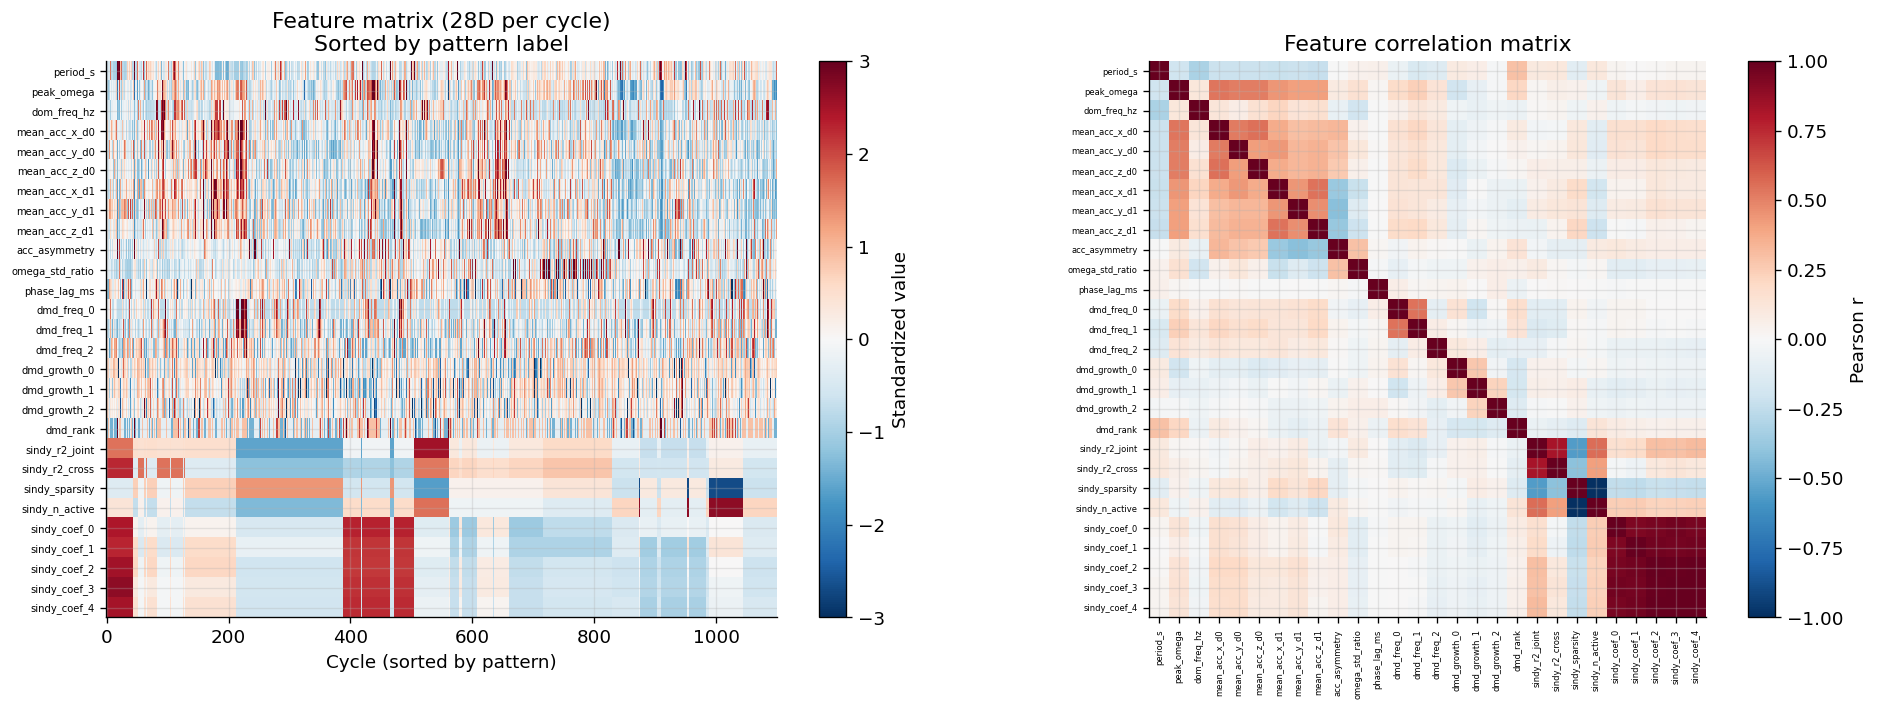

In [23]:
# ── Feature matrix visualization ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of standardized features (labeled only, sorted by pattern)
sort_idx = np.argsort(y_lab)
im = axes[0].imshow(X_lab_s[sort_idx].T, aspect='auto', cmap='RdBu_r',
                    interpolation='nearest', vmin=-3, vmax=3)
axes[0].set_yticks(range(N_FEAT))
axes[0].set_yticklabels(ALL_FEAT_NAMES, fontsize=6)
axes[0].set_xlabel('Cycle (sorted by pattern)')
axes[0].set_title(f'Feature matrix ({N_FEAT}D per cycle)\nSorted by pattern label')
plt.colorbar(im, ax=axes[0], label='Standardized value')

# Feature correlation matrix
corr = np.corrcoef(X_lab_s.T)
im2 = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
axes[1].set_xticks(range(N_FEAT))
axes[1].set_xticklabels(ALL_FEAT_NAMES, fontsize=5, rotation=90)
axes[1].set_yticks(range(N_FEAT))
axes[1].set_yticklabels(ALL_FEAT_NAMES, fontsize=5)
axes[1].set_title('Feature correlation matrix')
plt.colorbar(im2, ax=axes[1], label='Pearson r')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Pattern classification

### 7.1 Leave-one-session-out cross-validation (7-class)

LOSO-CV ensures no data leakage between cycles from the same session.  
Singleton classes (cheetahs_tail, race_and_chase, sneak_underhand — 1 session each)  
can never appear in both train and test simultaneously.

In [24]:
logo = LeaveOneGroupOut()
le   = LabelEncoder()
y_enc = le.fit_transform(y_lab)
n_classes = len(le.classes_)

y_pred_all = np.empty_like(y_enc)

fold_results = []
for fold, (train_idx, test_idx) in enumerate(logo.split(X_lab_s, y_enc, sid_lab)):
    rf = RandomForestClassifier(
        n_estimators=CONFIG['RF_N_ESTIMATORS'],
        class_weight='balanced',
        random_state=CONFIG['RANDOM_SEED'])
    rf.fit(X_lab_s[train_idx], y_enc[train_idx])
    y_pred_all[test_idx] = rf.predict(X_lab_s[test_idx])

    # Check if test class was in training set
    test_classes = set(y_enc[test_idx])
    train_classes = set(y_enc[train_idx])
    unseen = test_classes - train_classes
    if unseen:
        fold_results.append({
            'fold': fold,
            'session': sessions[sid_lab[test_idx[0]]]['name'],
            'note': f'unseen class(es): {[le.classes_[c] for c in unseen]}'
        })

# Report
print('7-class LOSO-CV results:\n')
print(classification_report(y_enc, y_pred_all, target_names=le.classes_))

f1_macro = f1_score(y_enc, y_pred_all, average='macro')
f1_weighted = f1_score(y_enc, y_pred_all, average='weighted')
print(f'F1 macro:    {f1_macro:.3f}')
print(f'F1 weighted: {f1_weighted:.3f}')

if fold_results:
    print(f'\nNote: {len(fold_results)} folds had unseen classes in test set '
          '(singleton patterns — cannot be in both train & test):')
    for r in fold_results[:5]:
        print(f'  {r["session"]}: {r["note"]}')

7-class LOSO-CV results:

                 precision    recall  f1-score   support

  cheetahs_tail       0.00      0.00      0.00        45
    dragon_roll       0.00      0.00      0.00       168
       overhand       0.00      0.00      0.00       292
 race_and_chase       0.00      0.00      0.00        58
 sneak_overhand       0.00      0.00      0.00       153
sneak_underhand       0.00      0.00      0.00       114
      underhand       0.26      0.32      0.29       270

       accuracy                           0.08      1100
      macro avg       0.04      0.05      0.04      1100
   weighted avg       0.06      0.08      0.07      1100

F1 macro:    0.041
F1 weighted: 0.071

Note: 3 folds had unseen classes in test set (singleton patterns — cannot be in both train & test):
  20260303_180119_race_and_chase_jo: unseen class(es): [np.str_('race_and_chase')]
  20260303_180712_sneak_underhand_jo: unseen class(es): [np.str_('sneak_underhand')]
  20260303_182756_cheetahs_tail_jo: u

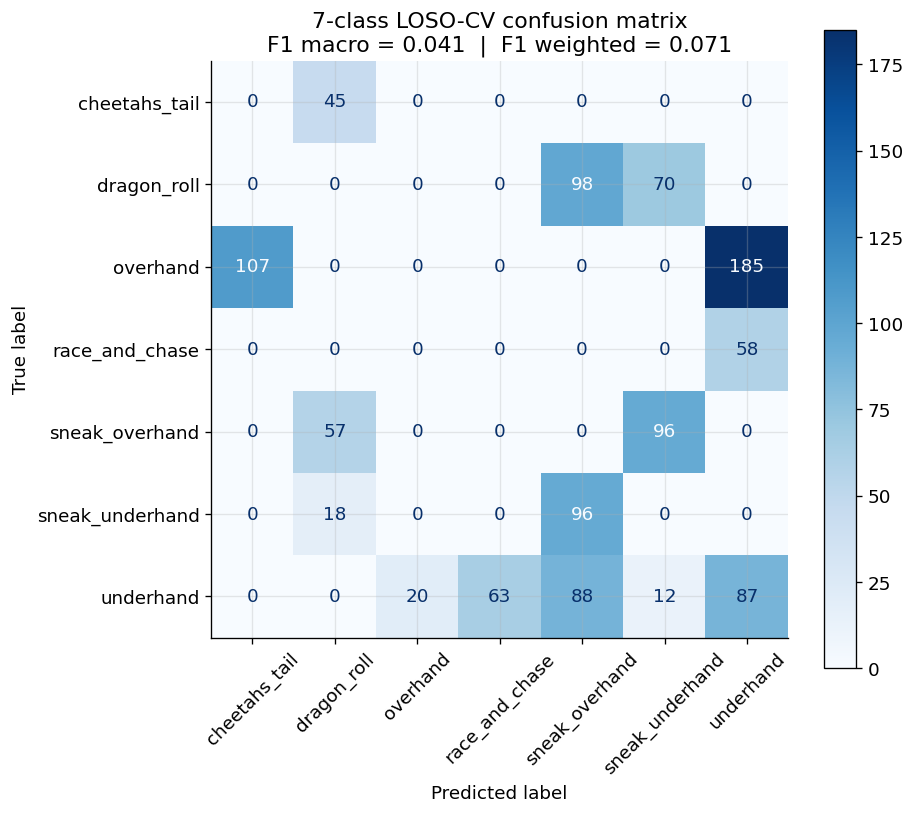

In [25]:
# ── Confusion matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_enc, y_pred_all)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title(f'7-class LOSO-CV confusion matrix\n'
             f'F1 macro = {f1_macro:.3f}  |  F1 weighted = {f1_weighted:.3f}')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_7class.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Grouped classification (3 macro-categories)

Addresses singleton-class limitation by grouping into:  
- **foundational**: underhand, overhand  
- **advanced**: dragon_roll, sneak_underhand, sneak_overhand  
- **hybrid**: race_and_chase, cheetahs_tail

3-class LOSO-CV results:

              precision    recall  f1-score   support

    advanced       0.58      0.78      0.66       435
foundational       0.61      0.56      0.58       562
      hybrid       0.00      0.00      0.00       103

    accuracy                           0.59      1100
   macro avg       0.40      0.44      0.41      1100
weighted avg       0.54      0.59      0.56      1100

F1 macro:    0.415
F1 weighted: 0.559


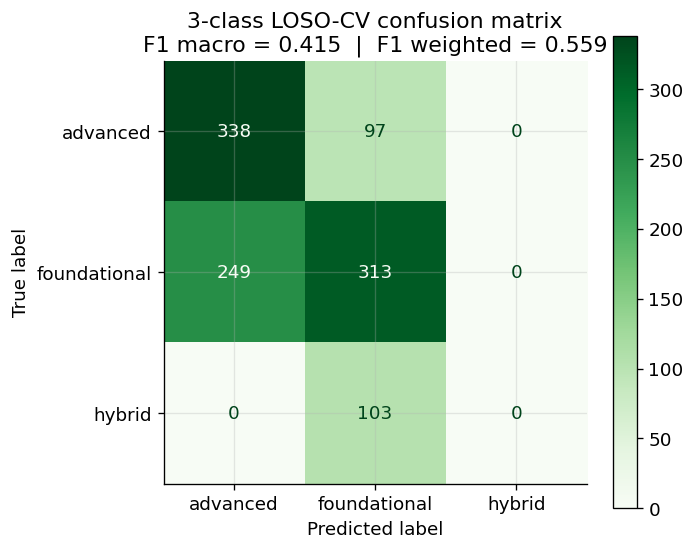

In [26]:
MACRO_MAP = {
    'underhand':       'foundational',
    'overhand':        'foundational',
    'dragon_roll':     'advanced',
    'sneak_underhand': 'advanced',
    'sneak_overhand':  'advanced',
    'race_and_chase':  'hybrid',
    'cheetahs_tail':   'hybrid',
}

y_macro     = np.array([MACRO_MAP[l] for l in y_lab])
le_macro    = LabelEncoder()
y_macro_enc = le_macro.fit_transform(y_macro)

y_pred_macro = np.empty_like(y_macro_enc)
for train_idx, test_idx in logo.split(X_lab_s, y_macro_enc, sid_lab):
    rf3 = RandomForestClassifier(
        n_estimators=CONFIG['RF_N_ESTIMATORS'],
        class_weight='balanced',
        random_state=CONFIG['RANDOM_SEED'])
    rf3.fit(X_lab_s[train_idx], y_macro_enc[train_idx])
    y_pred_macro[test_idx] = rf3.predict(X_lab_s[test_idx])

print('3-class LOSO-CV results:\n')
print(classification_report(y_macro_enc, y_pred_macro,
                            target_names=le_macro.classes_))

f1_macro_3 = f1_score(y_macro_enc, y_pred_macro, average='macro')
f1_weighted_3 = f1_score(y_macro_enc, y_pred_macro, average='weighted')
print(f'F1 macro:    {f1_macro_3:.3f}')
print(f'F1 weighted: {f1_weighted_3:.3f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm3 = confusion_matrix(y_macro_enc, y_pred_macro)
disp3 = ConfusionMatrixDisplay(cm3, display_labels=le_macro.classes_)
disp3.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'3-class LOSO-CV confusion matrix\n'
             f'F1 macro = {f1_macro_3:.3f}  |  F1 weighted = {f1_weighted_3:.3f}')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_3class.png'), dpi=150, bbox_inches='tight')
plt.show()

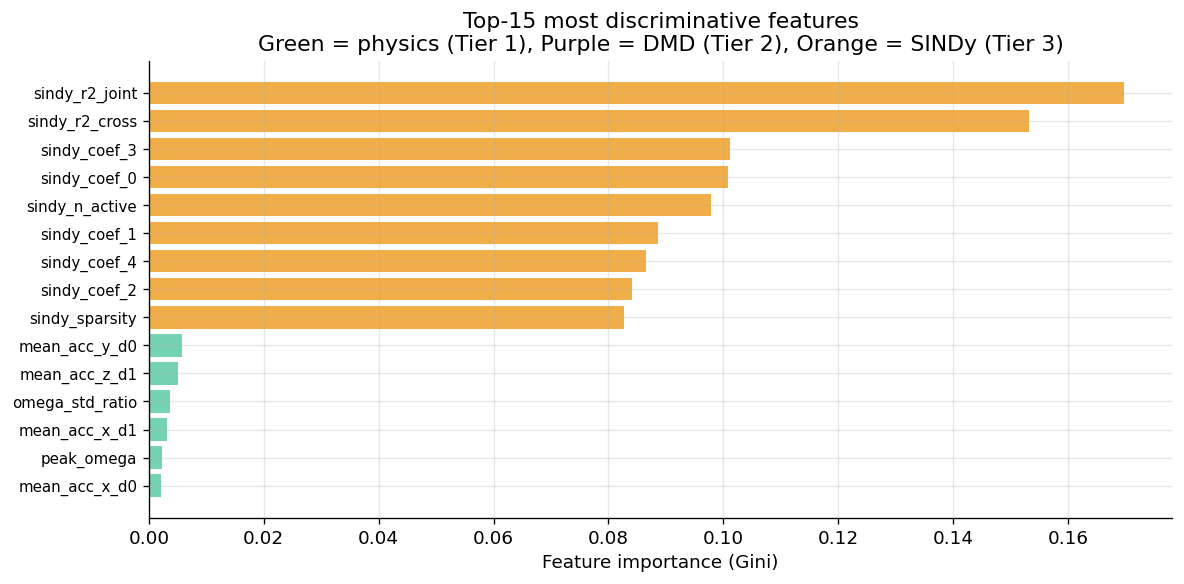

In [27]:
# ── Feature importance (trained on all labeled data) ──────────
rf_full = RandomForestClassifier(
    n_estimators=CONFIG['RF_N_ESTIMATORS'],
    class_weight='balanced',
    random_state=CONFIG['RANDOM_SEED'])
rf_full.fit(X_lab_s, y_enc)

imp = rf_full.feature_importances_
top_idx = np.argsort(imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_idx)), imp[top_idx][::-1],
        color=[PAL['dev0'] if i < 12 else (PAL['dev1'] if i < 19 else PAL['pinn'])
               for i in top_idx][::-1],
        alpha=0.85)
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([ALL_FEAT_NAMES[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel('Feature importance (Gini)')
ax.set_title('Top-15 most discriminative features\n'
             'Green = physics (Tier 1), Purple = DMD (Tier 2), Orange = SINDy (Tier 3)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Experimental sessions — unsupervised projection

Project experimental cycles into the labeled feature space via **t-SNE**.  
Predict their patterns using the trained Random Forest.

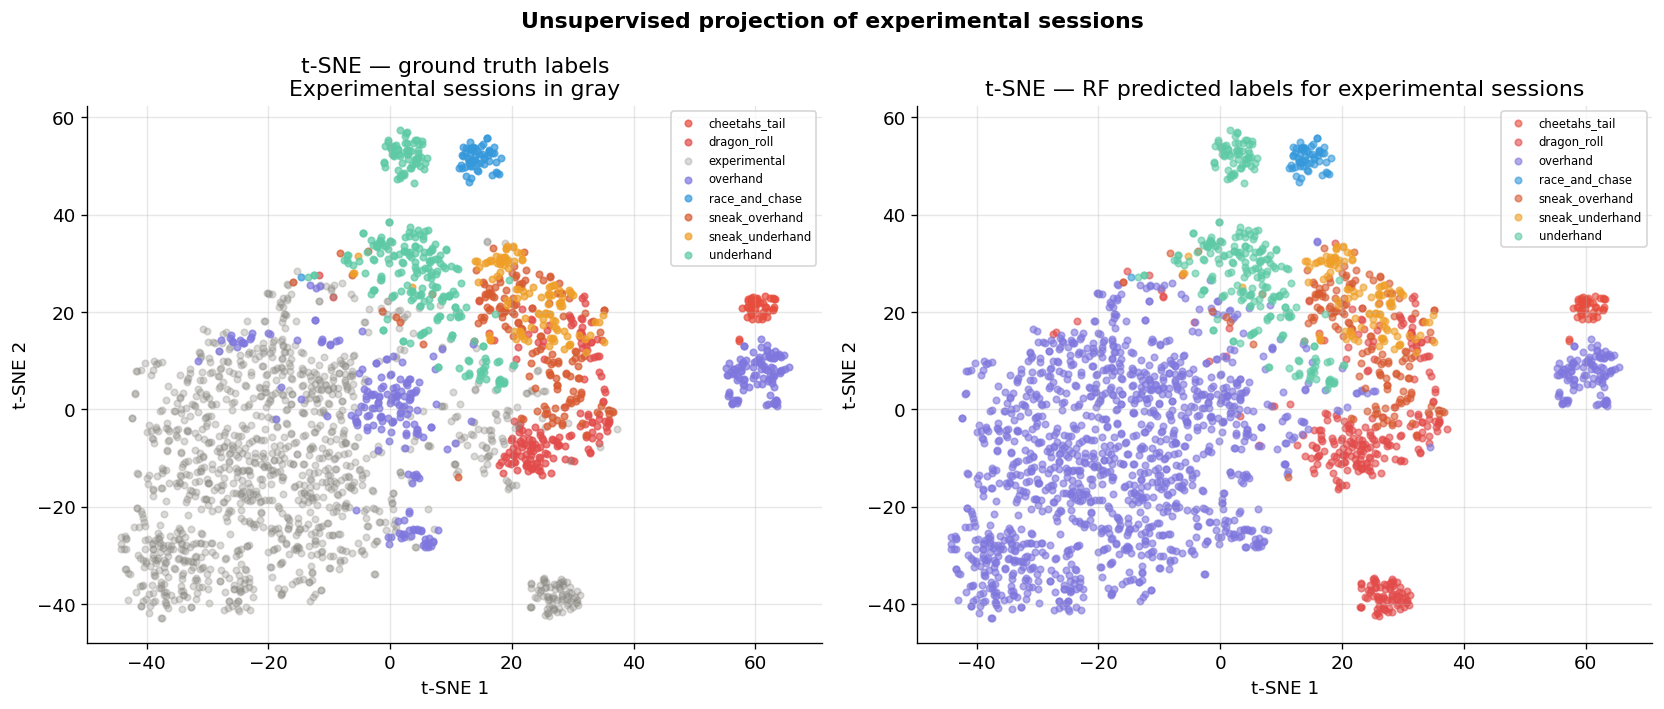

Experimental session predicted labels:
  overhand              1132 cycles (89.1%)
  dragon_roll            138 cycles (10.9%)


In [28]:
# ── t-SNE embedding of all cycles ────────────────────────────
X_all_s = np.vstack([X_lab_s, X_exp_s])
is_exp  = np.array([False]*len(X_lab_s) + [True]*len(X_exp_s))
y_all_plot = np.concatenate([y_lab, np.array(['experimental']*len(X_exp_s))])

tsne = TSNE(n_components=2, perplexity=min(30, len(X_all_s)//4),
            random_state=CONFIG['RANDOM_SEED'])
Z = tsne.fit_transform(X_all_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ground truth labels
for pat in sorted(set(y_all_plot)):
    mask = y_all_plot == pat
    col  = PAL.get(pat, PAL['gray'])
    alpha = 0.3 if pat == 'experimental' else 0.7
    axes[0].scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=alpha, color=col, label=pat)
axes[0].legend(fontsize=7, loc='best')
axes[0].set_title('t-SNE — ground truth labels\nExperimental sessions in gray')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# Right: RF predictions for experimental sessions
y_exp_pred = le.inverse_transform(rf_full.predict(X_exp_s))
y_pred_plot = np.concatenate([y_lab, y_exp_pred])

for pat in sorted(set(y_pred_plot)):
    mask = y_pred_plot == pat
    col  = PAL.get(pat, PAL['gray'])
    axes[1].scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=col, label=pat)
axes[1].legend(fontsize=7, loc='best')
axes[1].set_title('t-SNE — RF predicted labels for experimental sessions')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.suptitle('Unsupervised projection of experimental sessions', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tsne_projection.png'), dpi=150, bbox_inches='tight')
plt.show()

# Predicted distribution for experimental sessions
from collections import Counter
exp_dist = Counter(y_exp_pred)
print(f'Experimental session predicted labels:')
for pat, cnt in exp_dist.most_common():
    print(f'  {pat:<20s} {cnt:>5d} cycles ({100*cnt/len(y_exp_pred):.1f}%)')

---
## 8. Pipeline summary & ablation

Tier 1 only (physics)                 12D  F1_macro=0.043  F1_weighted=0.070
Tier 1+2 (physics + DMD)              19D  F1_macro=0.044  F1_weighted=0.067
Tier 1+2+3 (full pipeline)            28D  F1_macro=0.041  F1_weighted=0.071


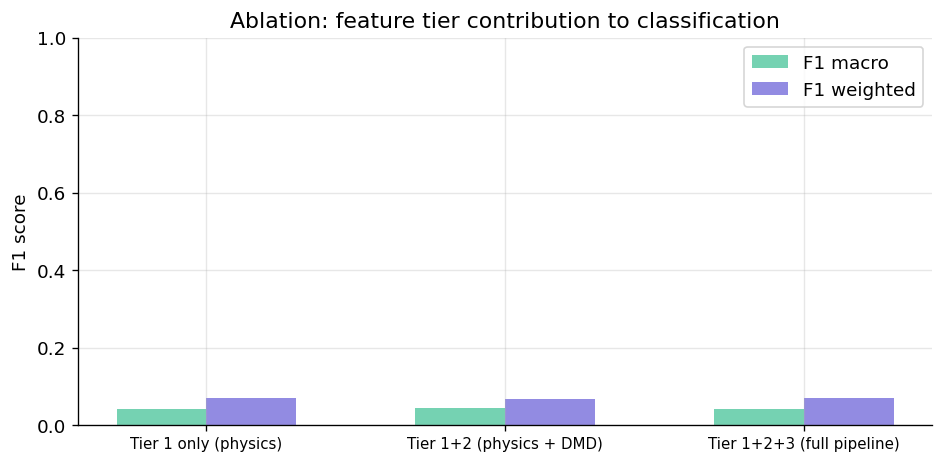

In [29]:
# ── Ablation: compare feature tiers ──────────────────────────
tier_configs = [
    ('Tier 1 only (physics)',       slice(0, 12)),
    ('Tier 1+2 (physics + DMD)',    slice(0, 19)),
    ('Tier 1+2+3 (full pipeline)',  slice(0, N_FEAT)),
]

ablation_results = []
for label, feat_slice in tier_configs:
    X_abl = X_lab[:, feat_slice]
    scaler_abl = StandardScaler()
    X_abl_s = scaler_abl.fit_transform(X_abl)

    y_pred_abl = np.empty_like(y_enc)
    for train_idx, test_idx in logo.split(X_abl_s, y_enc, sid_lab):
        rf_abl = RandomForestClassifier(
            n_estimators=CONFIG['RF_N_ESTIMATORS'],
            class_weight='balanced',
            random_state=CONFIG['RANDOM_SEED'])
        rf_abl.fit(X_abl_s[train_idx], y_enc[train_idx])
        y_pred_abl[test_idx] = rf_abl.predict(X_abl_s[test_idx])

    f1_m = f1_score(y_enc, y_pred_abl, average='macro')
    f1_w = f1_score(y_enc, y_pred_abl, average='weighted')
    ablation_results.append({'label': label, 'f1_macro': f1_m, 'f1_weighted': f1_w,
                             'n_feat': X_abl.shape[1]})
    print(f'{label:<35s}  {X_abl.shape[1]:>3d}D  '
          f'F1_macro={f1_m:.3f}  F1_weighted={f1_w:.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels_abl = [r['label'] for r in ablation_results]
x = np.arange(len(labels_abl))
ax.bar(x - 0.15, [r['f1_macro'] for r in ablation_results], 0.3,
       label='F1 macro', color=PAL['dev0'], alpha=0.85)
ax.bar(x + 0.15, [r['f1_weighted'] for r in ablation_results], 0.3,
       label='F1 weighted', color=PAL['dev1'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_abl, fontsize=9)
ax.set_ylabel('F1 score')
ax.set_title('Ablation: feature tier contribution to classification')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Pipeline summary ─────────────────────────────────────────
elapsed = time.time() - t_start

n_labeled_active = sum(s['is_labeled'] for s in active_sessions)
n_exp_active     = sum(not s['is_labeled'] for s in active_sessions)

print('=' * 60)
print('FULL PIPELINE SUMMARY')
print('=' * 60)

print(f'\nData')
print(f'  Sessions loaded:  {len(sessions)}')
print(f'  Sessions active:  {len(active_sessions)} ({n_labeled_active} labeled, '
      f'{n_exp_active} experimental)')
print(f'  Sessions skipped: {len(skipped_sessions)} (0 usable cycles)')
print(f'  Total cycles:     {len(X_all)} ({len(X_lab)} labeled, {len(X_exp)} experimental)')
print(f'  Pattern classes:  {n_classes} (7-class) / 3 (grouped)')

print(f'\nSINDy (per-session, joint fit, threshold={CONFIG["SINDY_THRESHOLD"]})')
r2s = [s['sindy']['r2_joint'] for s in active_sessions]
print(f'  R2 joint:  mean={np.mean(r2s):.4f}  std={np.std(r2s):.4f}')
sps = [s['sindy']['sparsity'] for s in active_sessions]
print(f'  Sparsity:  mean={np.mean(sps):.1%}')

print(f'\nTrajectory reconstruction')
bd0 = [s['baseline_drift0'] for s in active_sessions]
bd1 = [s['baseline_drift1'] for s in active_sessions]
print(f'  Baseline drift:  D0={np.mean(bd0):.4f} m  D1={np.mean(bd1):.4f} m')
print(f'  PINN:            {"enabled" if CONFIG["USE_PINN"] else "disabled"}')

print(f'\nDMD')
print(f'  Valid cycles:    {len(valid_ranks)}')
print(f'  Mean rank:       {np.mean(valid_ranks):.1f}')

print(f'\nClassification (LOSO-CV, Random Forest, {CONFIG["RF_N_ESTIMATORS"]} trees)')
print(f'  7-class:  F1 macro={f1_macro:.3f}  F1 weighted={f1_weighted:.3f}')
print(f'  3-class:  F1 macro={f1_macro_3:.3f}  F1 weighted={f1_weighted_3:.3f}')

print(f'\nFeatures: {N_FEAT}D per cycle')
print(f'  Tier 1 (physics):  {len(TIER1_NAMES)}D')
print(f'  Tier 2 (DMD):      {len(TIER2_NAMES)}D')
print(f'  Tier 3 (SINDy):    {len(TIER3_NAMES)}D')

print(f'\nAblation (7-class F1 macro):')
for r in ablation_results:
    print(f'  {r["label"]:<35s} {r["f1_macro"]:.3f}')

if skipped_sessions:
    print(f'\nSkipped sessions:')
    for s in skipped_sessions:
        print(f'  {s["name"]}: {s["skip_reason"]}')

print(f'\nWall time: {elapsed:.1f} s ({elapsed/60:.1f} min)')
print('=' * 60)